# Run 4: CORSIKA Event Analysis

This notebook analyzes the manifest generated by `run4_Corsika_EventGenerator.ipynb`, validates the sampled primary phase space, and diagnoses failed or timed-out CORSIKA events.


## 1. Libraries and Parameters

This section loads the analysis dependencies and defines the minimal filesystem paths required to read the CORSIKA event campaign.


### 1.1 Libraries

In [1]:
from __future__ import annotations
%matplotlib inline

from dataclasses import dataclass
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


### 1.2. Paths

In [2]:
PATH_CORSIKA_ROOT = "/home/juan/hep/opt/corsika8-install"
RUN = "run_3"

DEFAULT_OUTPUT_ROOT = Path(r"/mnt/v/output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))
OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the original notebook code.
PATH_OUTPUT_ROOT = OUTPUT_ROOT
PATH_OUTPUT_CORSIKA = OUTPUT_CORSIKA_ROOT
PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_CORSIKA_GENERATOR.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
PATH_CRMODEL_FILE = Path(PATH_OUTPUT_RUN / "cosmic_ray_model.h5")
PATH_PRIMARIES_FILE = Path(PATH_OUTPUT_RUN / "primaries_000003.csv")
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")
PATH_DATASET_NEUTRINO_FILE = Path(PATH_OUTPUT_RUN / "dataset_neutrino_test.h5")
PATH_OUTPUT_RUN.mkdir(parents=True, exist_ok=True)

print(" Configured workflow paths:\n", "=" * 80)
print(" - PATH_CORSIKA_ROOT = ", PATH_CORSIKA_ROOT)
print(" - DEFAULT_OUTPUT_ROOT = ", DEFAULT_OUTPUT_ROOT)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - RUN = ", RUN, "\n")

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_RUN       = ", PATH_OUTPUT_RUN)
print(" - PATH_CRMODEL_FILE     = ", PATH_CRMODEL_FILE)
print(" - PATH_PRIMARIES_FILE   = ", PATH_PRIMARIES_FILE)
print(" - PATH_MANIFEST_FILE    = ", PATH_MANIFEST_FILE)
print(" - PATH_DATASET_NEUTRINO_FILE  = ", PATH_DATASET_NEUTRINO_FILE)


 Configured workflow paths:
 - PATH_CORSIKA_ROOT =  /home/juan/hep/opt/corsika8-install
 - DEFAULT_OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_DATA_ROOT =  /mnt/v/output/data
 - OUTPUT_CORSIKA_ROOT =  /mnt/v/output/data/corsika
 - RUN =  run_3 

 Output paths:
 - PATH_OUTPUT_RUN       =  /mnt/v/output/data/corsika/generator/run_3
 - PATH_CRMODEL_FILE     =  /mnt/v/output/data/corsika/generator/run_3/cosmic_ray_model.h5
 - PATH_PRIMARIES_FILE   =  /mnt/v/output/data/corsika/generator/run_3/primaries_000003.csv
 - PATH_MANIFEST_FILE    =  /mnt/v/output/data/corsika/generator/run_3/manifest.csv
 - PATH_DATASET_NEUTRINO_FILE  =  /mnt/v/output/data/corsika/generator/run_3/dataset_neutrino_test.h5


### 1.3. Configuration

In [3]:


@dataclass(frozen=True)
class Config:
    """Minimal paths required for Run 3 analysis notebooks."""
    output_root: Path = Path(PATH_OUTPUT_RUN)
    manifest_path: Path = Path(PATH_MANIFEST_FILE)
    corsika_root: Path = Path(PATH_CORSIKA_ROOT)


CONFIG = Config(
    output_root=Path(PATH_OUTPUT_RUN),
    manifest_path=Path(PATH_MANIFEST_FILE),
    corsika_root=Path(PATH_CORSIKA_ROOT),
)

print("Paths")
print("-" * 72)
print(f"output_root  : {CONFIG.output_root}")
print(f"manifest_path: {CONFIG.manifest_path}")
print(f"corsika_root : {CONFIG.corsika_root}")
print(f"manifest exists: {CONFIG.manifest_path.exists()}")


Paths
------------------------------------------------------------------------
output_root  : /mnt/v/output/data/corsika/generator/run_3
manifest_path: /mnt/v/output/data/corsika/generator/run_3/manifest.csv
corsika_root : /home/juan/hep/opt/corsika8-install
manifest exists: True


## 2. Manifest Analysis

This section reloads the event manifest and checks the phase-space coverage of simulated primaries.


### 2.1 Manifest Loading and Preview

This subsection shows the latest manifest rows, counts event statuses, and lists problematic simulations for quick inspection.


In [4]:
manifest = pd.read_csv(CONFIG.manifest_path)
display(manifest.tail())
display(manifest["status"].value_counts())

,event_id,status,returncode,output_dir,stdout_log,stderr_log,elapsed_seconds,command,corsika_id,primary_mnemonic,primary_name,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,primary_weight,p_real,q_sim,importance_ratio,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau
3757,7783,done,0,generator/run_3/event_00007783,generator/run_3/_logs/event_00007783/stdout.log,generator/run_3/_logs/event_00007783/stderr.log,713.527195,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 6 -A 12 -E 52214.9138109 -z 59.5485371735 -a 311.621796665 --observation-level 0 --track-neutrinos -N 1 -s 7825 --verbosit...,1206,C,carbon,6,12,0,52214.913811,59.548537,311.621797,71290.130499,1.397174e-08,7.196084e-15,1.900685e-11,0.000379,5967,1654,4313,0
3758,7774,done,0,generator/run_3/event_00007774,generator/run_3/_logs/event_00007774/stdout.log,generator/run_3/_logs/event_00007774/stderr.log,2315.762127,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 14 -A 28 -E 140617.870344 -z 47.7727990688 -a 280.401694245 --observation-level 0 --track-neutrinos -N 1 -s 7816 --verbosi...,2814,Si,silicon,14,28,0,140617.870344,47.772799,280.401694,72029.507602,1.291120e-09,5.712754e-16,1.632840e-11,0.000035,15483,4237,11246,0
3759,7798,done,0,generator/run_3/event_00007798,generator/run_3/_logs/event_00007798/stdout.log,generator/run_3/_logs/event_00007798/stderr.log,14.790376,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 8 -A 16 -E 1123.05004727 -z 17.5389263169 -a 221.996755051 --observation-level 0 --track-neutrinos -N 1 -s 7840 --verbosit...,1608,O,oxygen,8,16,0,1123.050047,17.538926,221.996755,97942.926388,1.204824e-05,2.135178e-12,6.539963e-12,0.326482,0,0,0,0
3760,7800,done,0,generator/run_3/event_00007800,generator/run_3/_logs/event_00007800/stdout.log,generator/run_3/_logs/event_00007800/stderr.log,16.088786,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 6 -A 12 -E 759.4438413 -z 34.4132188439 -a 180.718506349 --observation-level 0 --track-neutrinos -N 1 -s 7842 --verbosity ...,1206,C,carbon,6,12,0,759.443841,34.413219,180.718506,6083.155561,1.584602e-05,5.294941e-12,1.233121e-11,0.429393,0,0,0,0
3761,7728,timeout,-124,generator/run_3/event_00007728,generator/run_3/_logs/event_00007728/stdout.log,generator/run_3/_logs/event_00007728/stderr.log,3600.057027,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 13 -A 26 -E 397509.322246 -z 82.6949467488 -a 230.307840519 --observation-level 0 --track-neutrinos -N 1 -s 7770 --verbosi...,2613,Al,aluminium,13,26,0,397509.322246,82.694947,230.307841,9539.005484,5.223318e-11,3.085730e-17,2.180099e-11,0.000001,0,0,0,0


status
done       2870
timeout     469
failed      423
Name: count, dtype: int64

In [5]:
# Section 6 diagnostic: list failed or timed-out events for quick triage.
problem_status = {"failed", "timeout", "skipped_existing_no_done"}
problem_events = manifest[manifest["status"].isin(problem_status)].copy()
print(f"Problem events: {len(problem_events)}")
if not problem_events.empty:
    display(problem_events[["event_id", "status", "returncode", "elapsed_seconds", "stderr_log"]].head(20))


Problem events: 892


,event_id,status,returncode,elapsed_seconds,stderr_log
23,0,failed,77,1466.819532,generator/run_3/_logs/event_00000000/stderr.log
31,63,failed,-6,272.771067,generator/run_3/_logs/event_00000063/stderr.log
32,73,failed,77,73.244865,generator/run_3/_logs/event_00000073/stderr.log
41,55,failed,77,1554.492619,generator/run_3/_logs/event_00000055/stderr.log
45,58,failed,77,1380.738575,generator/run_3/_logs/event_00000058/stderr.log
53,89,failed,77,968.933216,generator/run_3/_logs/event_00000089/stderr.log
60,7,timeout,-124,3600.061087,generator/run_3/_logs/event_00000007/stderr.log
61,32,timeout,-124,3600.039882,generator/run_3/_logs/event_00000032/stderr.log
66,52,timeout,-124,3600.034986,generator/run_3/_logs/event_00000052/stderr.log
77,104,failed,77,2150.757496,generator/run_3/_logs/event_00000104/stderr.log


### 2.2 Final Validation Plots

This subsection joins primary metadata with the manifest and visualizes energy, angle, observation height, and execution-time distributions.


,event_id,status,returncode,output_dir,stdout_log,stderr_log,elapsed_seconds,command,corsika_id,primary_mnemonic,primary_name,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,primary_weight,p_real,q_sim,importance_ratio,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau,corsika_id_primary,primary_mnemonic_primary,primary_name_primary,Z_primary,A_primary,pdg_primary,E0_GeV_primary,theta0_deg_primary,phi0_deg_primary,observation_level_m_primary,primary_weight_primary,p_real_primary,q_sim_primary,importance_ratio_primary,seed
0,25,done,0,generator/run_3/event_00000025,generator/run_3/_logs/event_00000025/stdout.log,generator/run_3/_logs/event_00000025/stderr.log,11.710589,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 6 -A 12 -E 704.793930847 -z 11.9935402473 -a 116.964332793 --observation-level 0 --track-neutrinos -N 1 -s 67 --verbosity ...,1206,C,carbon,6,12,0,704.793931,11.993540,116.964333,59039.710097,1.776930e-05,2.266221e-12,4.706483e-12,0.481510,0,0,0,0,1206,C,carbon,6,12,0,704.793931,11.993540,116.964333,59039.710097,1.776930e-05,2.266221e-12,4.706483e-12,0.481510,67
1,4,done,0,generator/run_3/event_00000004,generator/run_3/_logs/event_00000004/stdout.log,generator/run_3/_logs/event_00000004/stderr.log,11.763054,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 2 -A 4 -E 163.421265867 -z 31.972819578 -a 77.7873573922 --observation-level 0 --track-neutrinos -N 1 -s 46 --verbosity wa...,402,He,helium,2,4,0,163.421266,31.972820,77.787357,44371.038114,1.047036e-03,3.318355e-10,1.169569e-11,28.372460,0,0,0,0,402,He,helium,2,4,0,163.421266,31.972820,77.787357,44371.038114,1.047036e-03,3.318355e-10,1.169569e-11,28.372460,46
2,26,done,0,generator/run_3/event_00000026,generator/run_3/_logs/event_00000026/stdout.log,generator/run_3/_logs/event_00000026/stderr.log,12.274764,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 12 -A 24 -E 644.050185091 -z 39.159350368 -a 242.486842274 --observation-level 0 --track-neutrinos -N 1 -s 68 --verbosity ...,2412,Mg,magnesium,12,24,0,644.050185,39.159350,242.486842,78700.633434,1.562324e-05,5.865238e-12,1.385412e-11,0.423357,0,0,0,0,2412,Mg,magnesium,12,24,0,644.050185,39.159350,242.486842,78700.633434,1.562324e-05,5.865238e-12,1.385412e-11,0.423357,68
3,30,done,0,generator/run_3/event_00000030,generator/run_3/_logs/event_00000030/stdout.log,generator/run_3/_logs/event_00000030/stderr.log,9.503437,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 25 -A 50 -E 1425.42884452 -z 50.7685162284 -a 222.818527483 --observation-level 0 --track-neutrinos -N 1 -s 72 --verbosity...,5025,Mn,manganese,25,50,0,1425.428845,50.768516,222.818527,2706.765234,7.551182e-07,3.492568e-13,1.706847e-11,0.020462,0,0,0,0,5025,Mn,manganese,25,50,0,1425.428845,50.768516,222.818527,2706.765234,7.551182e-07,3.492568e-13,1.706847e-11,0.020462,72
4,34,done,0,generator/run_3/event_00000034,generator/run_3/_logs/event_00000034/stdout.log,generator/run_3/_logs/event_00000034/stderr.log,10.451845,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 12 -A 24 -E 982.923704999 -z 54.1273365321 -a 351.41274971 --observation-level 0 --track-neutrinos -N 1 -s 76 --verbosity ...,2412,Mg,magnesium,12,24,0,982.923705,54.127337,351.412750,63654.951325,7.745259e-06,3.728056e-12,1.776279e-11,0.209880,0,0,0,0,2412,Mg,magnesium,12,24,0,982.923705,54.127337,351.412750,63654.951325,7.745259e-06,3.728056e-12,1.776279e-11,0.209880,76


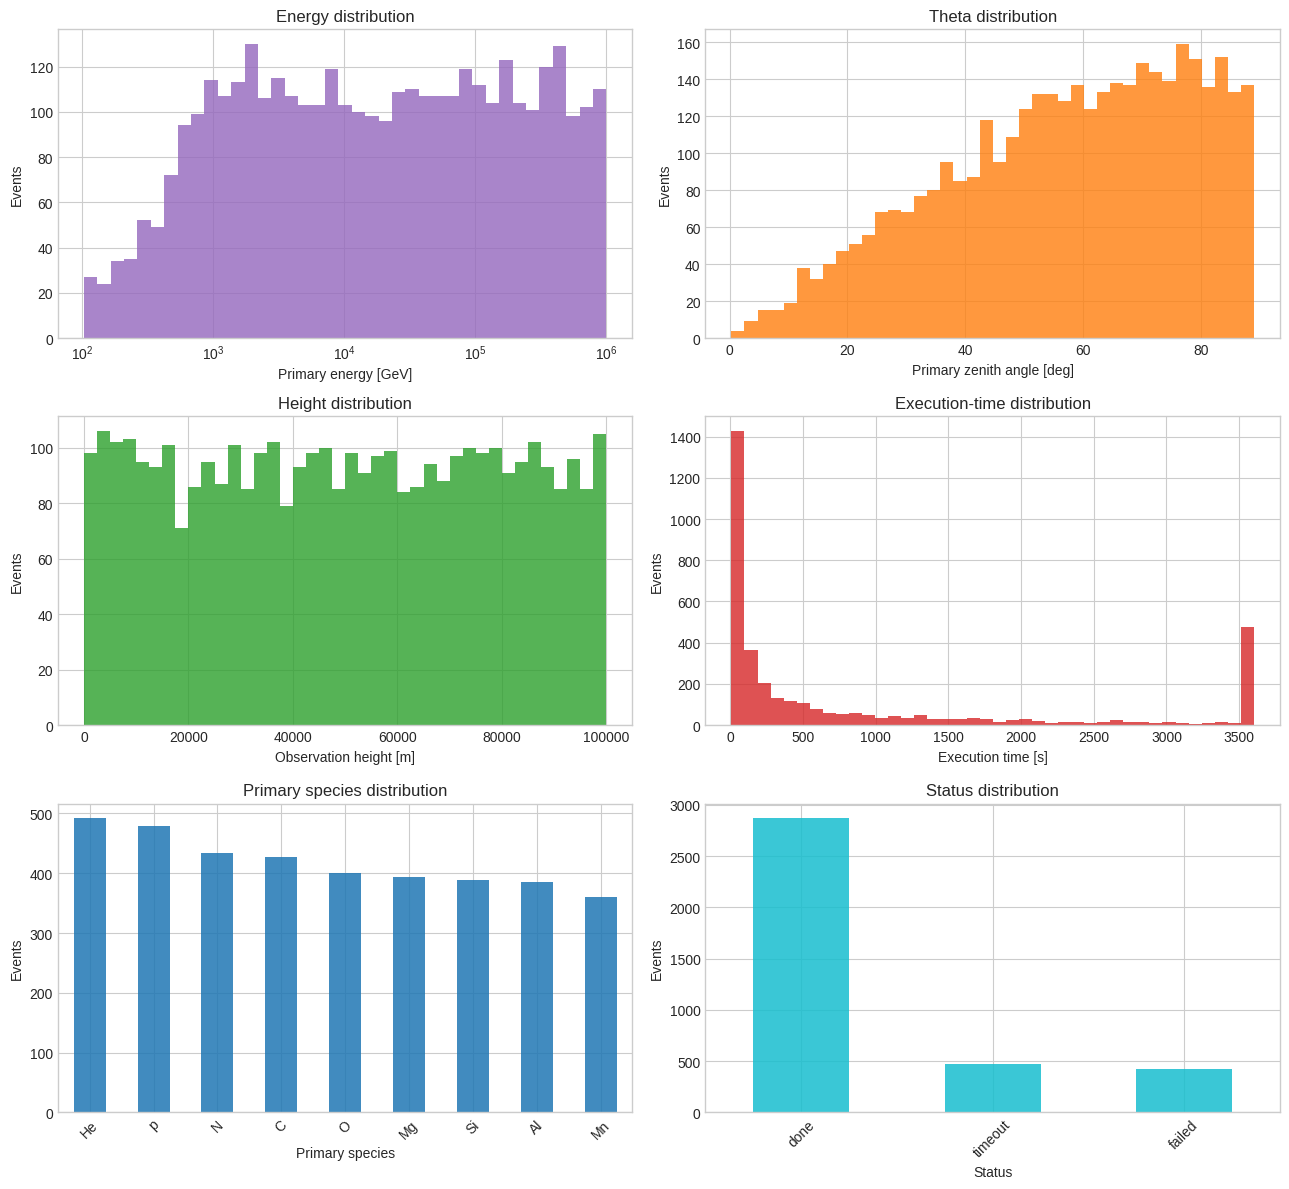

In [6]:
def load_primary_metadata_for_manifest(manifest: pd.DataFrame, output_root: Path) -> pd.DataFrame:
    """Load per-event primary metadata and join it with the execution manifest."""

    metadata_rows = []
    for event_id in manifest["event_id"].astype(int):
        metadata_path = output_root / "_primaries" / f"event_{event_id:08d}.csv"
        if not metadata_path.exists():
            continue
        row = pd.read_csv(metadata_path).iloc[0].to_dict()
        metadata_rows.append(row)

    metadata = pd.DataFrame(metadata_rows)
    if metadata.empty:
        return manifest.copy()

    metadata["event_id"] = metadata["event_id"].astype(int)
    joined = manifest.merge(metadata, on="event_id", how="left", suffixes=("", "_primary"))
    return joined


validation_table = load_primary_metadata_for_manifest(manifest, CONFIG.output_root)
display(validation_table.head())

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

primary_energy = validation_table.loc[validation_table["E0_GeV"] > 0, "E0_GeV"].dropna()
if primary_energy.empty:
    axes[0, 0].text(0.5, 0.5, "No valid primary energy values", ha="center", va="center")
    axes[0, 0].set_axis_off()
else:
    energy_bins = np.logspace(np.log10(primary_energy.min()), np.log10(primary_energy.max()), 40)
    axes[0, 0].hist(primary_energy, bins=energy_bins, color="tab:purple", alpha=0.8)
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_xlabel("Primary energy [GeV]")
    axes[0, 0].set_ylabel("Events")
    axes[0, 0].set_title("Energy distribution")

axes[0, 1].hist(validation_table["theta0_deg"].dropna(), bins=40, color="tab:orange", alpha=0.8)
axes[0, 1].set_xlabel("Primary zenith angle [deg]")
axes[0, 1].set_ylabel("Events")
axes[0, 1].set_title("Theta distribution")

axes[1, 0].hist(validation_table["observation_level_m"].dropna(), bins=40, color="tab:green", alpha=0.8)
axes[1, 0].set_xlabel("Observation height [m]")
axes[1, 0].set_ylabel("Events")
axes[1, 0].set_title("Height distribution")

axes[1, 1].hist(validation_table["elapsed_seconds"].dropna(), bins=40, color="tab:red", alpha=0.8)
axes[1, 1].set_xlabel("Execution time [s]")
axes[1, 1].set_ylabel("Events")
axes[1, 1].set_title("Execution-time distribution")

primary_column = "primary_mnemonic" if "primary_mnemonic" in validation_table.columns else "corsika_id"
primary_counts = validation_table[primary_column].fillna("unknown").astype(str).value_counts()
primary_counts.plot(kind="bar", ax=axes[2, 0], color="tab:blue", alpha=0.85)
axes[2, 0].set_xlabel("Primary species")
axes[2, 0].set_ylabel("Events")
axes[2, 0].set_title("Primary species distribution")
axes[2, 0].tick_params(axis="x", rotation=45)

status_counts = validation_table["status"].fillna("unknown").astype(str).value_counts()
status_counts.plot(kind="bar", ax=axes[2, 1], color="tab:cyan", alpha=0.85)
axes[2, 1].set_xlabel("Status")
axes[2, 1].set_ylabel("Events")
axes[2, 1].set_title("Status distribution")
axes[2, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3. Error Analysis

This section focuses on failed and timed-out simulations, grouped by return code, primary energy, and primary species.


### 3.1 Runtime and Failed/Timeout Energy Distributions

This subsection keeps execution time versus primary energy and compares the primary-energy distributions of failed and timed-out events.


Failed events in energy histogram: 423
Timeout events in energy histogram: 469


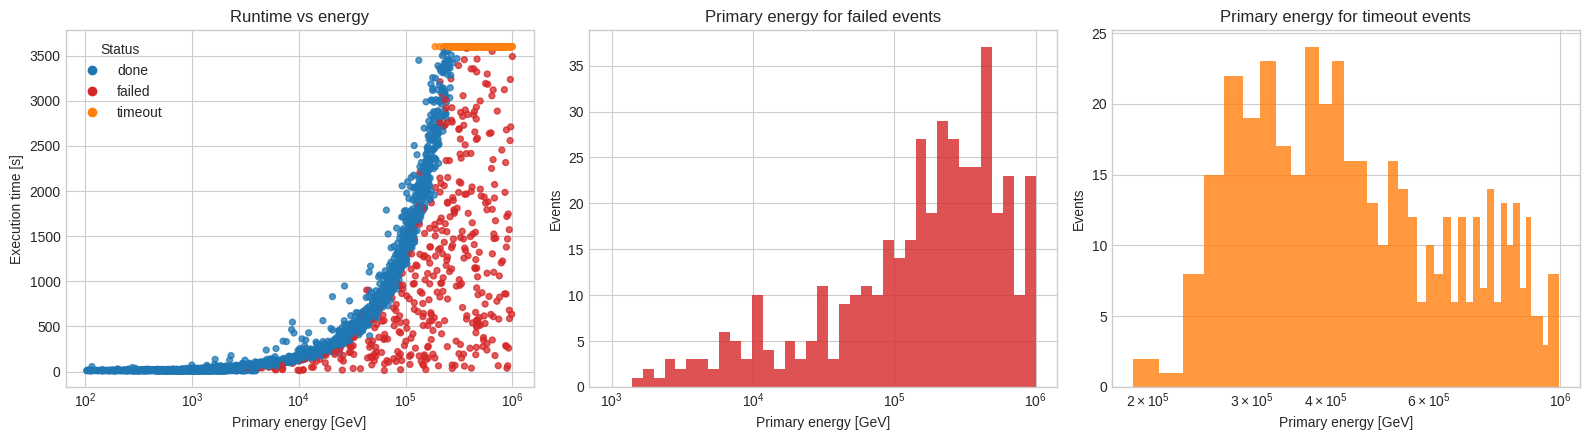

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_table = validation_table.dropna(subset=["elapsed_seconds", "E0_GeV"]).copy()

status_colors = {
    "done": "tab:blue",
    "failed": "tab:red",
    "timeout": "tab:orange",
    "skipped_done": "tab:green",
    "skipped_existing_no_done": "tab:gray",
}
colors = plot_table["status"].map(status_colors).fillna("tab:gray")

axes[0].scatter(plot_table["E0_GeV"], plot_table["elapsed_seconds"], c=colors, s=18, alpha=0.75)
axes[0].set_xscale("log")
axes[0].set_xlabel("Primary energy [GeV]")
axes[0].set_ylabel("Execution time [s]")
axes[0].set_title("Runtime vs energy")

failed_events = plot_table.loc[plot_table["status"].eq("failed"), "E0_GeV"].dropna()
if failed_events.empty:
    axes[1].text(0.5, 0.5, "No failed events", ha="center", va="center")
    axes[1].set_axis_off()
else:
    energy_bins = np.logspace(np.log10(failed_events.min()), np.log10(failed_events.max()), 40)
    
    axes[1].hist(failed_events, bins=energy_bins, color="tab:red", alpha=0.8)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Primary energy [GeV]")
    axes[1].set_ylabel("Events")
    axes[1].set_title("Primary energy for failed events")

timeout_events = plot_table.loc[plot_table["status"].eq("timeout"), "E0_GeV"].dropna()
if timeout_events.empty:
    axes[2].text(0.5, 0.5, "No timeout events", ha="center", va="center")
    axes[2].set_axis_off()
else:
    axes[2].hist(timeout_events, bins=40, color="tab:orange", alpha=0.8)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Primary energy [GeV]")
    axes[2].set_ylabel("Events")
    axes[2].set_title("Primary energy for timeout events")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=status)
    for status, color in status_colors.items()
    if status in set(plot_table["status"])
]
if handles:
    axes[0].legend(handles=handles, title="Status", loc="best")

print(f"Failed events in energy histogram: {len(failed_events)}")
print(f"Timeout events in energy histogram: {len(timeout_events)}")

plt.tight_layout()
plt.show()


### 3.2 Failed Simulations by Code, Energy, and Primary

This subsection summarizes failed simulations with histograms by return code, primary energy, and primary species.


Failed simulations included in this diagnostic: 423


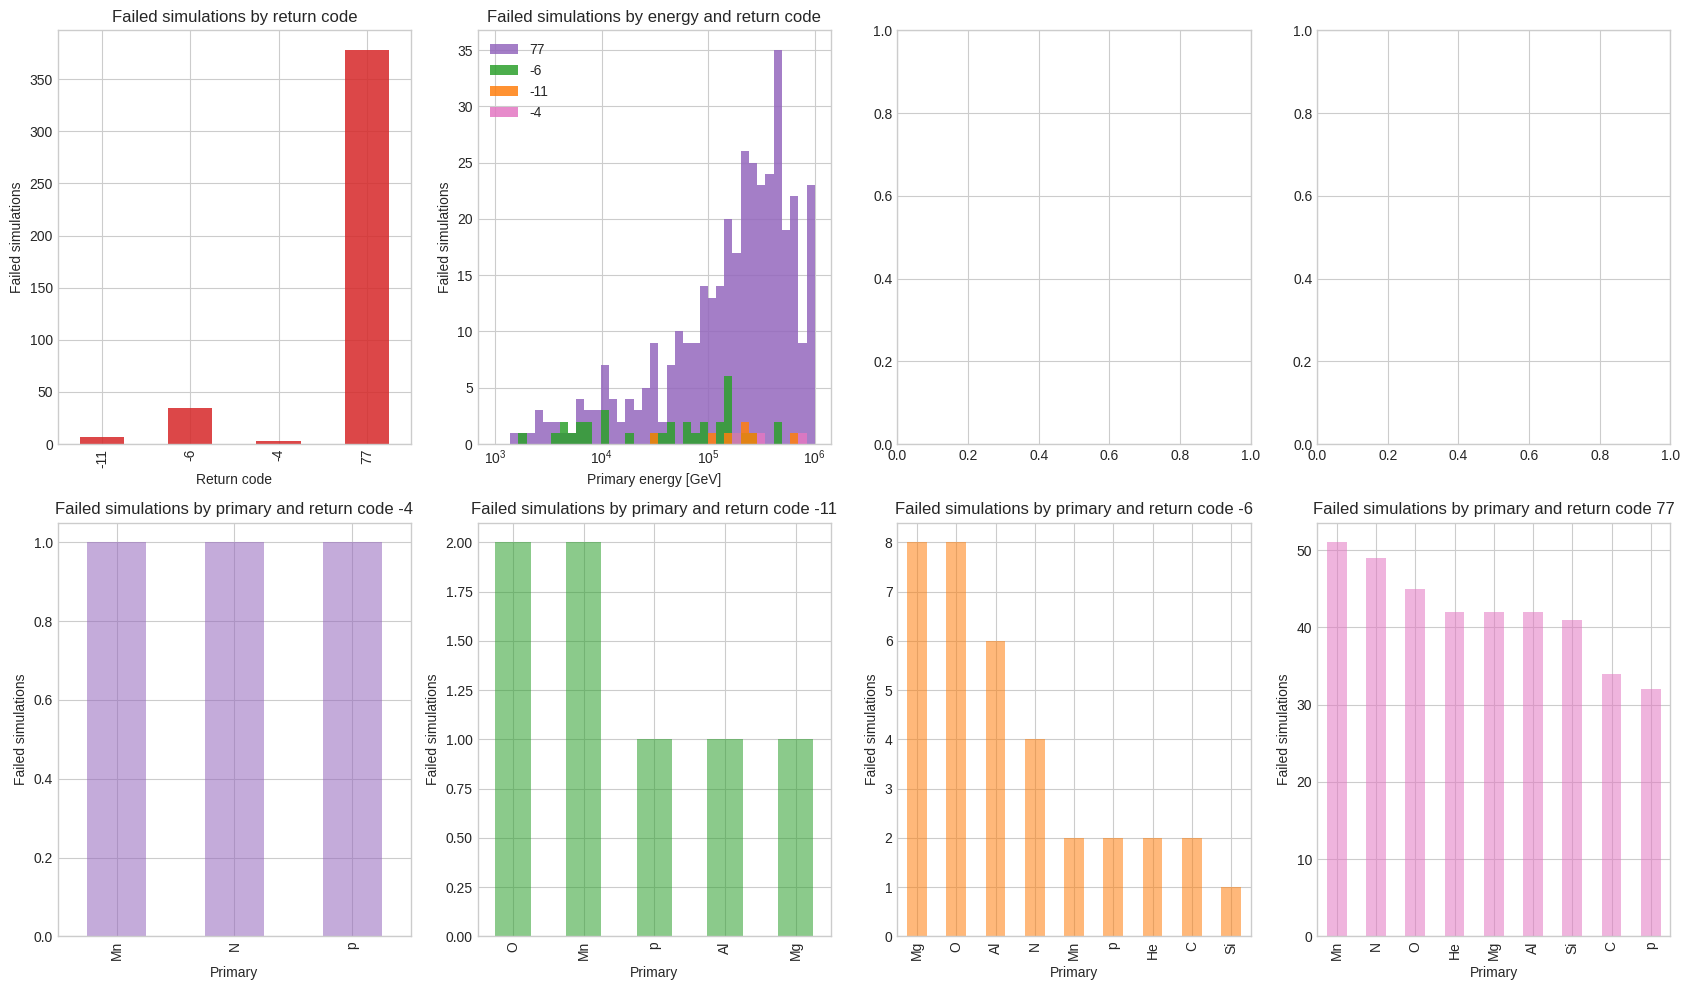

,returncode,primary_mnemonic,failed_events
21,77,Mn,51
22,77,N,49
23,77,O,45
17,77,Al,42
20,77,Mg,42
19,77,He,42
24,77,Si,41
18,77,C,34
25,77,p,32
8,-6,Mg,8


In [8]:
failed_table = validation_table[validation_table["status"].eq("failed")].copy()
returncode_list = failed_table['returncode'].unique()
primary_list = failed_table['primary_mnemonic'].unique()
colors = ["tab:purple", "tab:green", "tab:orange", "tab:pink"]

print(f"Failed simulations included in this diagnostic: {len(failed_table)}")
if failed_table.empty:
    print("No failed simulations available for the failed-event histogram diagnostics.")
else:
    fig, axes = plt.subplots(2, 4, figsize=(17, 10))

    returncode_counts = failed_table["returncode"].value_counts(dropna=False).sort_index()
    returncode_counts.plot(kind="bar", ax=axes[0,0], color="tab:red", alpha=0.85)
    axes[0,0].set_xlabel("Return code")
    axes[0,0].set_ylabel("Failed simulations")
    axes[0,0].set_title("Failed simulations by return code")

    failed_energy = failed_table.loc[failed_table["E0_GeV"] > 0, "E0_GeV"].dropna()
    if failed_energy.empty:
        axes[0,1].text(0.5, 0.5, "No valid primary energy values", ha="center", va="center")
        axes[0,1].set_axis_off()
    else:
        energy_bins = np.logspace(np.log10(failed_energy.min()), np.log10(failed_energy.max()), 40)
        for ix, code in enumerate(returncode_list):
            failed_code = failed_table[failed_table['returncode']==code]
            failed_energy = failed_code.loc[failed_code["E0_GeV"] > 0, "E0_GeV"].dropna()
            axes[0,1].hist(failed_energy, bins=energy_bins, color=colors[ix], alpha=0.85, label = str(code))
        #axes[1].hist(failed_energy, bins=energy_bins, color="tab:purple", alpha=0.85)
        axes[0,1].set_xscale("log")
        axes[0,1].set_xlabel("Primary energy [GeV]")
        axes[0,1].set_ylabel("Failed simulations")
        axes[0,1].set_title("Failed simulations by energy and return code")
        axes[0,1].legend()

    for ix, code in enumerate(reversed(returncode_list)):
        
        failed_code = failed_table[failed_table['returncode']==code]
        primary_column = "primary_mnemonic" if "primary_mnemonic" in failed_code.columns else "corsika_id"
        primary_counts = failed_code[primary_column].fillna("unknown").astype(str).value_counts()
        primary_counts.plot(kind="bar", ax=axes[1,ix], color=colors[ix], alpha=0.55, label = str(code))
        
        axes[1,ix].set_xlabel("Primary")
        axes[1,ix].set_ylabel("Failed simulations")
        axes[1,ix].set_title(f"Failed simulations by primary and return code {str(code)}")
        
    plt.tight_layout()
    plt.show()

    display(
        failed_table.groupby(["returncode", primary_column], dropna=False)
        .size()
        .rename("failed_events")
        .reset_index()
        .sort_values("failed_events", ascending=False)
        .head(30)
    )


### 3.3 Failed Simulation Scatter by Return Code

This subsection draws one panel per return code, with primary energy on a logarithmic X axis and primary species on the Y axis.


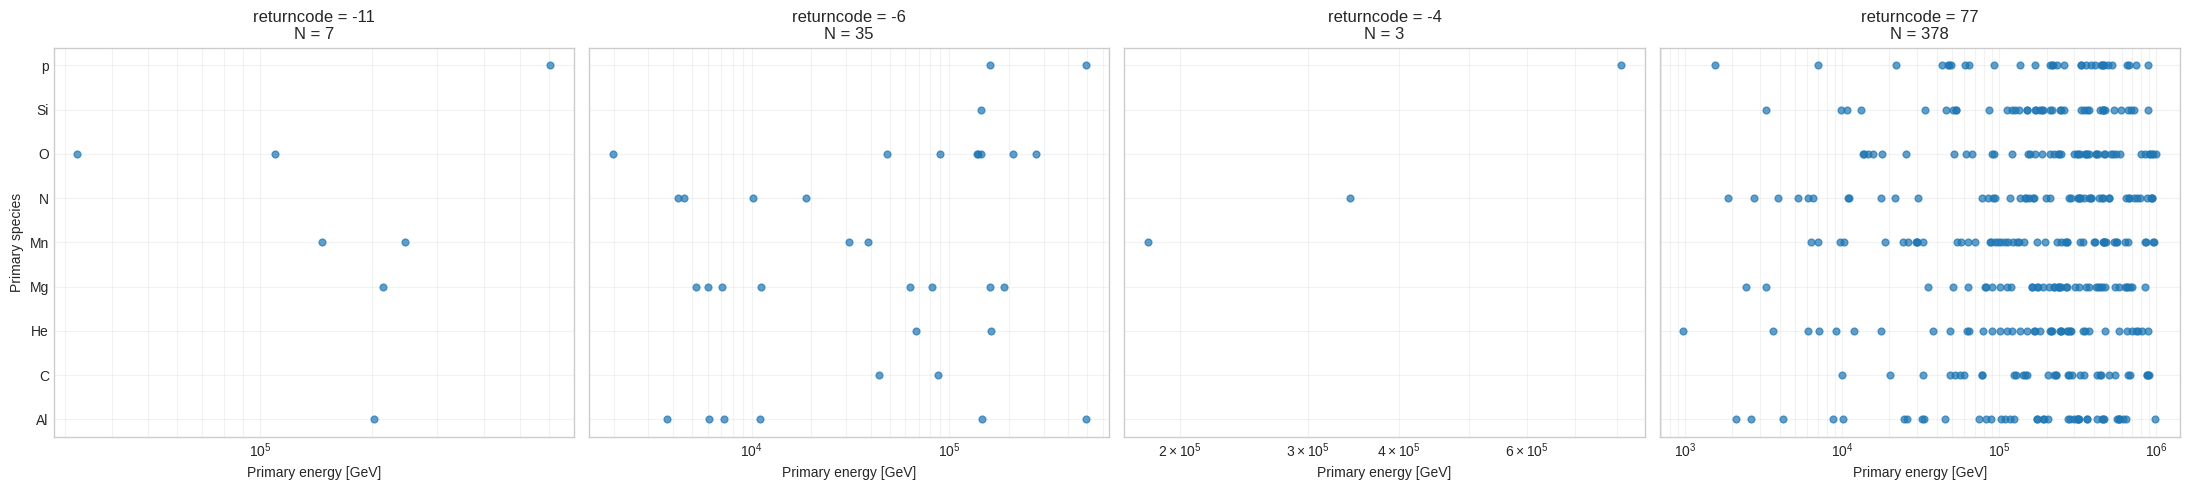

,returncode,primary_label,events,min_E0_GeV,median_E0_GeV,max_E0_GeV
2,-11,Mn,2,146934.795217,196479.005618,246023.216019
3,-11,O,2,32289.618828,71092.778873,109895.938917
0,-11,Al,1,203201.165549,203201.165549,203201.165549
1,-11,Mg,1,214637.825775,214637.825775,214637.825775
4,-11,p,1,604284.168066,604284.168066,604284.168066
8,-6,Mg,8,5235.357152,37185.706712,188103.314704
11,-6,O,8,1980.143881,138728.815607,275324.926126
5,-6,Al,6,3710.476915,9099.741112,489395.042654
10,-6,N,4,4251.469287,7370.689208,18924.559153
6,-6,C,2,44041.166491,65735.555182,87429.943874


In [9]:
failed_scatter = validation_table[validation_table["status"].eq("failed")].copy()

if failed_scatter.empty:
    print("No failed simulations available for return-code scatter plots.")
else:
    primary_column = "primary_mnemonic" if "primary_mnemonic" in failed_scatter.columns else "corsika_id"
    failed_scatter = failed_scatter.dropna(subset=["E0_GeV", primary_column, "returncode"]).copy()
    failed_scatter = failed_scatter[failed_scatter["E0_GeV"] > 0]
    failed_scatter["primary_label"] = failed_scatter[primary_column].astype(str)

    return_codes = sorted(failed_scatter["returncode"].dropna().unique())
    n_codes = len(return_codes)
    fig, axes = plt.subplots(1, n_codes, figsize=(5.5 * n_codes, 5), sharey=True)
    axes = np.atleast_1d(axes)

    primary_order = sorted(failed_scatter["primary_label"].unique())
    primary_to_y = {name: idx for idx, name in enumerate(primary_order)}

    for ax, return_code in zip(axes, return_codes):
        subset = failed_scatter[failed_scatter["returncode"].eq(return_code)].copy()
        y = subset["primary_label"].map(primary_to_y)
        ax.scatter(subset["E0_GeV"], y, s=24, alpha=0.7)
        ax.set_xscale("log")
        ax.set_xlabel("Primary energy [GeV]")
        ax.set_title(f"returncode = {return_code:g}\nN = {len(subset)}")
        ax.grid(True, which="both", alpha=0.25)

    axes[0].set_yticks(range(len(primary_order)))
    axes[0].set_yticklabels(primary_order)
    axes[0].set_ylabel("Primary species")

    plt.tight_layout()
    plt.show()

    display(
        failed_scatter.groupby(["returncode", "primary_label"])
        .agg(events=("event_id", "count"), min_E0_GeV=("E0_GeV", "min"), median_E0_GeV=("E0_GeV", "median"), max_E0_GeV=("E0_GeV", "max"))
        .reset_index()
        .sort_values(["returncode", "events"], ascending=[True, False])
    )
